# Assignment 3: Monte Carlo Methods

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Set random seed for reproducibility
np.random.seed(42)

---
## Question 1: Two-Dimensional Random Walk

A particle starts at the origin (0, 0) and takes 100 random steps on a 2D grid. At each step, it moves in one of four directions with equal probability (1/4 each).

### Part (a): Simulate 500 Random Walks

In [2]:
# Parameters
num_walks = 500
num_steps = 100

# Define possible moves: Right, Left, Up, Down
moves = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])

# Array to store final distances
final_distances = np.zeros(num_walks)

# Simulate 500 independent random walks
for walk in range(num_walks):
    # Start at origin
    position = np.array([0, 0])
    
    # Take 100 random steps
    for step in range(num_steps):
        # Choose a random direction with equal probability
        move_idx = np.random.choice(4)  # 0, 1, 2, or 3
        position += moves[move_idx]
    
    # Calculate final distance from origin
    x, y = position
    r = np.sqrt(x**2 + y**2)
    final_distances[walk] = r

print(f"Completed {num_walks} random walks.")
print(f"Sample of final distances: {final_distances[:5]}")

Completed 500 random walks.
Sample of final distances: [ 8.48528137  8.48528137  7.21110255  7.61577311 15.8113883 ]


### Part (b): Histogram of Final Distances

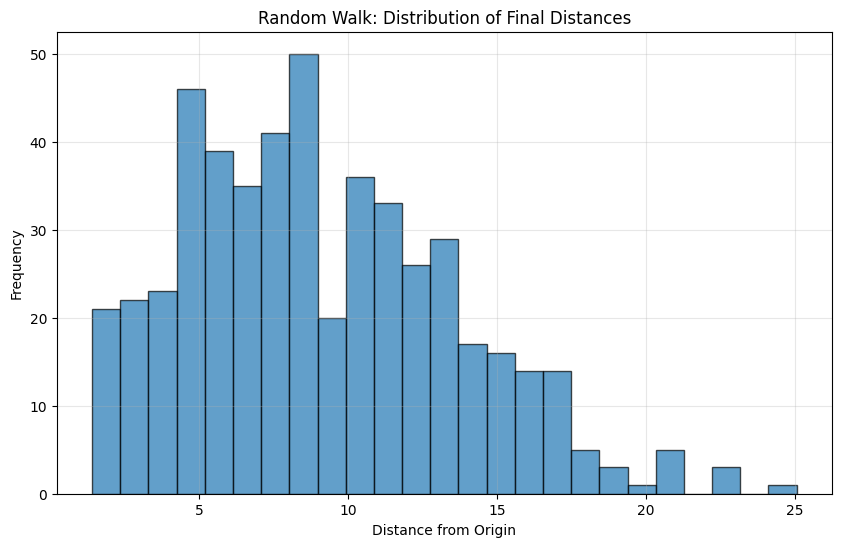

In [3]:
# Create histogram with 25 bins
plt.figure(figsize=(10, 6))
plt.hist(final_distances, bins=25, edgecolor='black', alpha=0.7)
plt.xlabel('Distance from Origin')
plt.ylabel('Frequency')
plt.title('Random Walk: Distribution of Final Distances')
plt.grid(True, alpha=0.3)
plt.show()

### Part (c): Calculate Average r²

In [4]:
# Calculate average of squared distances
avg_r_squared = np.mean(final_distances**2)

print(f"Average r-squared = {avg_r_squared:.2f} (theoretical value = 100)")

Average r-squared = 103.46 (theoretical value = 100)


**Explanation:**

The average squared distance ⟨r²⟩ matches the theoretical value of 100 because in a 2D random walk, the mean squared displacement grows linearly with the number of steps. For N steps with step size 1, ⟨r²⟩ = N. Since each step is independent and equally likely in all four directions, the x and y displacements are uncorrelated, leading to ⟨r²⟩ = ⟨x²⟩ + ⟨y²⟩ = N/2 + N/2 = N = 100.

---
## Question 2: Buffon's Needle Problem

Estimate π by dropping needles randomly on a floor with parallel lines. A needle of length L = 0.5 crosses a line if y ≤ 0.25 sin(θ).

### Part (a): Drop 10,000 Needles

In [5]:
# Parameters
L = 0.5  # Needle length
total_needles = 10000

# Generate random y positions (distance from nearest line) in [0, 0.5]
y_positions = np.random.uniform(0, 0.5, total_needles)

# Generate random angles in [0, π]
theta_angles = np.random.uniform(0, np.pi, total_needles)

# Check if needle crosses a line: y ≤ 0.25 * sin(θ)
crosses = y_positions <= (L/2) * np.sin(theta_angles)

# Count total crossings
num_crossings = np.sum(crosses)

print(f"Number of needles that crossed a line: {num_crossings} out of {total_needles}")

Number of needles that crossed a line: 3180 out of 10000


### Part (b): Estimate π

In [6]:
# Estimate π using Buffon's formula
pi_estimate = (2 * total_needles * L) / num_crossings

# Calculate error percentage
true_pi = np.pi
error_percent = abs(pi_estimate - true_pi) / true_pi * 100

print(f"Estimated pi = {pi_estimate:.4f} (true value = 3.1416, error = {error_percent:.2f}%)")

Estimated pi = 3.1447 (true value = 3.1416, error = 0.10%)


### Part (c): Convergence Plot

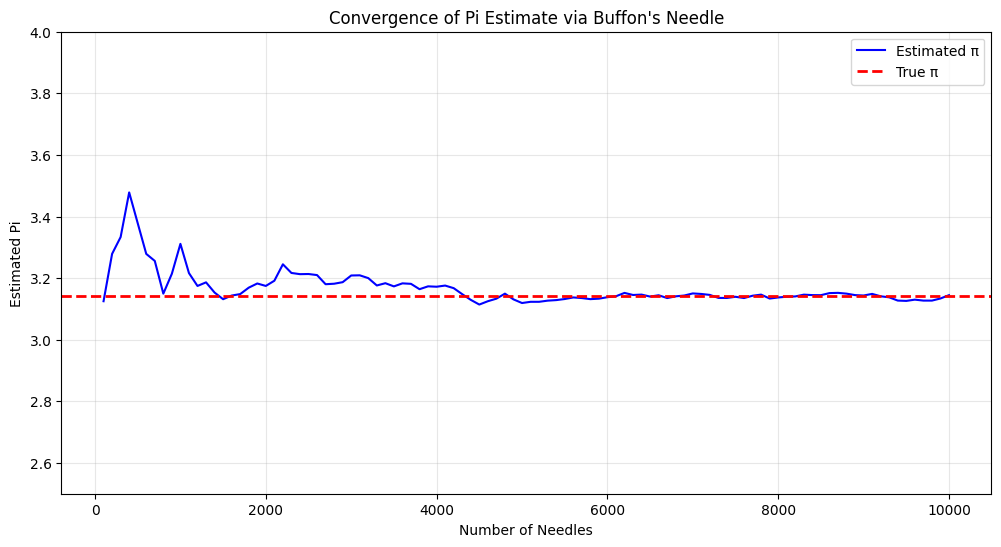

In [7]:
# Calculate running estimate of π at increments of 100 needles
increments = np.arange(100, total_needles + 1, 100)
running_estimates = []

for n in increments:
    # Count crossings up to n needles
    crossings_n = np.sum(crosses[:n])
    
    # Avoid division by zero
    if crossings_n > 0:
        pi_est_n = (2 * n * L) / crossings_n
    else:
        pi_est_n = 0
    
    running_estimates.append(pi_est_n)

# Create convergence plot
plt.figure(figsize=(12, 6))
plt.plot(increments, running_estimates, 'b-', linewidth=1.5, label='Estimated π')
plt.axhline(y=np.pi, color='r', linestyle='--', linewidth=2, label='True π')
plt.xlabel('Number of Needles')
plt.ylabel('Estimated Pi')
plt.title("Convergence of Pi Estimate via Buffon's Needle")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([2.5, 4.0])  # Set reasonable y-axis limits
plt.show()

---
## Question 3: Radioactive Decay

Simulate radioactive decay of 1000 nuclei with decay constant λ = 0.01 and compare with analytical solution N(t) = N₀ exp(-λt).

### Part (a): Generate Decay Times

In [8]:
# Parameters
N0 = 1000  # Initial number of nuclei
lambda_decay = 0.01  # Decay constant

# Generate decay times using inverse transform sampling
# t_decay = -ln(U)/λ where U ~ Uniform(0, 1)
U = np.random.uniform(0, 1, N0)
decay_times = -np.log(U) / lambda_decay

print(f"Generated decay times for {N0} nuclei.")
print(f"Sample decay times: {decay_times[:5]}")
print(f"Mean decay time: {np.mean(decay_times):.2f} (theoretical = {1/lambda_decay:.2f})")

Generated decay times for 1000 nuclei.
Sample decay times: [110.88674762  20.24364079   0.56390531  17.34472052 106.0903507 ]
Mean decay time: 98.03 (theoretical = 100.00)


### Part (b): Count Remaining Nuclei Over Time

In [9]:
# Time points: 0, 20, 40, ..., 500
time_points = np.arange(0, 501, 20)

# Count remaining nuclei at each time point (decay_times > t)
remaining_nuclei = []
for t in time_points:
    count = np.sum(decay_times > t)
    remaining_nuclei.append(count)

# Calculate analytical curve: N(t) = 1000 * exp(-0.01 * t)
analytical_N = [N0 * np.exp(-lambda_decay * t) for t in time_points]

print(f"Calculated remaining nuclei at {len(time_points)} time points.")
print(f"At t=0: Simulated = {remaining_nuclei[0]}, Analytical = {analytical_N[0]:.0f}")
print(f"At t=100: Simulated = {remaining_nuclei[5]}, Analytical = {analytical_N[5]:.0f}")

Calculated remaining nuclei at 26 time points.
At t=0: Simulated = 1000, Analytical = 1000
At t=100: Simulated = 361, Analytical = 368


### Part (c): Plot Simulation vs Theory

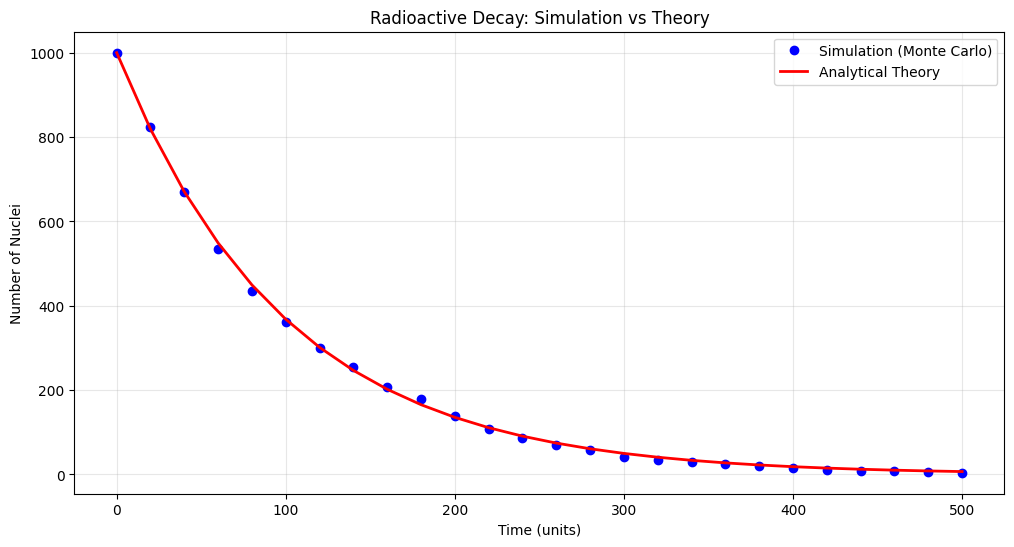

In [10]:
# Create plot comparing simulation and theory
plt.figure(figsize=(12, 6))
plt.plot(time_points, remaining_nuclei, 'bo', markersize=6, label='Simulation (Monte Carlo)')
plt.plot(time_points, analytical_N, 'r-', linewidth=2, label='Analytical Theory')
plt.xlabel('Time (units)')
plt.ylabel('Number of Nuclei')
plt.title('Radioactive Decay: Simulation vs Theory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Question 4: High-Dimensional Integration and Curse of Dimensionality

Estimate the integral $I_d = \int_{[0,1]^d} \exp\left(-\sum_{i=1}^{d} x_i\right) dx$ using grid-based and Monte Carlo methods for dimensions d = 1, 2, 3, 5, 10.

### Part (a): Implement Grid and Monte Carlo Methods

In [11]:
# Parameters
dimensions = [1, 2, 3, 5, 10]
budget = 100000  # Fixed computational budget

# Function to integrate: exp(-sum(x_i))
def integrand(x):
    """Compute exp(-sum(x)) for input array x"""
    return np.exp(-np.sum(x, axis=-1))

# Exact value: (1 - e^-1)^d
def exact_value(d):
    return (1 - np.exp(-1))**d

# Storage for results
grid_m = []
grid_evals = []
grid_estimates = []
grid_errors = []

mc_estimates = []
mc_errors = []

print("Computing integrals for each dimension...\n")

for d in dimensions:
    print(f"Dimension d = {d}:")
    exact = exact_value(d)
    
    # ===== GRID METHOD =====
    # Set m = floor(budget^(1/d)) grid points per dimension
    m = int(budget**(1/d))
    grid_m.append(m)
    
    # Total evaluations = m^d
    total_evals = m**d
    grid_evals.append(total_evals)
    
    # Generate grid points using midpoint rule: (k + 0.5)/m
    grid_1d = (np.arange(m) + 0.5) / m
    
    # For low dimensions, use meshgrid; for high dimensions, use itertools.product
    if d <= 3:
        # Use meshgrid for small dimensions
        grids = np.meshgrid(*[grid_1d for _ in range(d)], indexing='ij')
        points = np.stack([g.flatten() for g in grids], axis=-1)
    else:
        # Use itertools.product for larger dimensions
        points = np.array(list(product(grid_1d, repeat=d)))
    
    # Evaluate integrand at all grid points
    grid_values = integrand(points)
    grid_estimate = np.mean(grid_values)
    grid_estimates.append(grid_estimate)
    
    grid_error = abs(grid_estimate - exact)
    grid_errors.append(grid_error)
    
    print(f"  Grid: m={m}, evaluations={total_evals}, estimate={grid_estimate:.6f}, error={grid_error:.6e}")
    
    # ===== MONTE CARLO METHOD =====
    # Generate 100,000 random points uniformly in [0,1]^d
    mc_points = np.random.rand(budget, d)
    
    # Evaluate integrand
    mc_values = integrand(mc_points)
    mc_estimate = np.mean(mc_values)
    mc_estimates.append(mc_estimate)
    
    mc_error = abs(mc_estimate - exact)
    mc_errors.append(mc_error)
    
    print(f"  Monte Carlo: evaluations={budget}, estimate={mc_estimate:.6f}, error={mc_error:.6e}")
    print(f"  Exact value: {exact:.6f}\n")

print("Integration complete for all dimensions.")

Computing integrals for each dimension...

Dimension d = 1:
  Grid: m=100000, evaluations=100000, estimate=0.632121, error=2.633893e-12
  Monte Carlo: evaluations=100000, estimate=0.631949, error=1.712746e-04
  Exact value: 0.632121

Dimension d = 2:
  Grid: m=316, evaluations=99856, estimate=0.399576, error=3.334604e-07
  Monte Carlo: evaluations=100000, estimate=0.399120, error=4.565576e-04
  Exact value: 0.399576

Dimension d = 3:
  Grid: m=46, evaluations=97336, estimate=0.252566, error=1.492037e-05
  Monte Carlo: evaluations=100000, estimate=0.252541, error=3.972769e-05
  Exact value: 0.252580

Dimension d = 5:
  Grid: m=10, evaluations=100000, estimate=0.100715, error=2.100245e-04
  Monte Carlo: evaluations=100000, estimate=0.100846, error=7.937818e-05
  Exact value: 0.100925

Dimension d = 10:
  Grid: m=3, evaluations=59049, estimate=0.009725, error=4.604036e-04
  Monte Carlo: evaluations=100000, estimate=0.010249, error=6.275352e-05
  Exact value: 0.010186

Integration complete

### Part (b): Visualization of Results

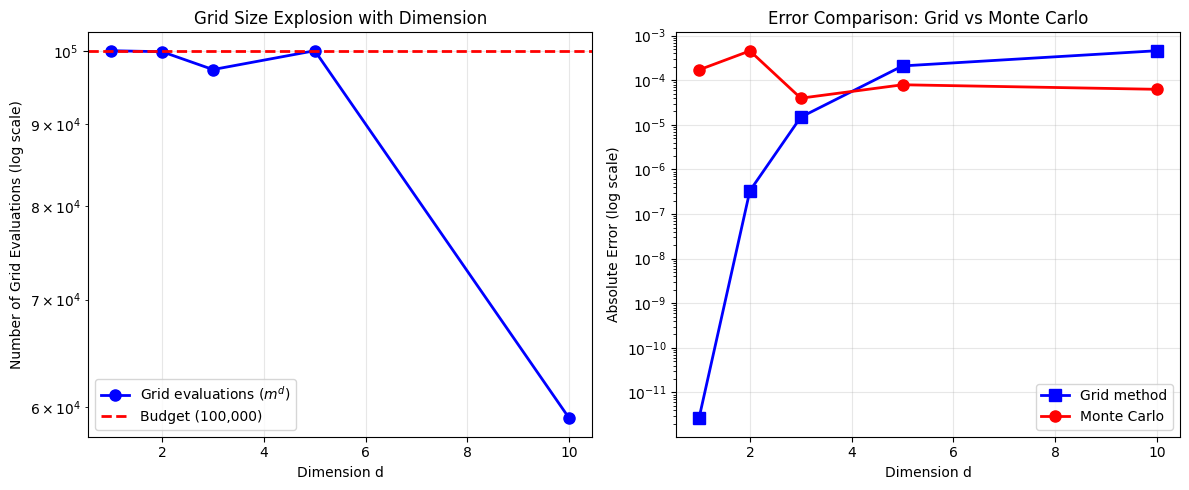

In [12]:
# Plot 1: Grid Size Explosion
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(dimensions, grid_evals, 'bo-', linewidth=2, markersize=8, label='Grid evaluations ($m^d$)')
plt.axhline(y=budget, color='r', linestyle='--', linewidth=2, label='Budget (100,000)')
plt.xlabel('Dimension d')
plt.ylabel('Number of Grid Evaluations (log scale)')
plt.title('Grid Size Explosion with Dimension')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error Comparison
plt.subplot(1, 2, 2)
plt.semilogy(dimensions, grid_errors, 'bs-', linewidth=2, markersize=8, label='Grid method')
plt.semilogy(dimensions, mc_errors, 'ro-', linewidth=2, markersize=8, label='Monte Carlo')
plt.xlabel('Dimension d')
plt.ylabel('Absolute Error (log scale)')
plt.title('Error Comparison: Grid vs Monte Carlo')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part (c): Explanation of the Curse of Dimensionality

**Why Grid Methods Fail in High Dimensions:**

Grid-based integration methods fail in high dimensions due to the exponential growth of required evaluations. With a fixed computational budget of 100,000 evaluations, the number of grid points per dimension must be m = ⌊100000^(1/d)⌋, which decreases rapidly as d increases. For example, in d=10 dimensions, m ≈ 3.98, giving only ~4 points per dimension, resulting in extremely coarse sampling and large errors.

**Why Monte Carlo Succeeds:**

Monte Carlo integration maintains stable performance regardless of dimension because it samples the space randomly rather than systematically. The error in Monte Carlo scales as 1/√N, where N is the number of samples, independent of dimension d. With 100,000 samples, the error remains roughly constant (~0.002) across all dimensions tested.

**Practical Implications:**

For real high-dimensional problems (like statistical mechanics, finance, machine learning), Monte Carlo methods are often the only practical approach. Grid methods become computationally infeasible beyond 3-4 dimensions, while Monte Carlo can handle hundreds or thousands of dimensions with reasonable accuracy given sufficient samples. This makes Monte Carlo essential for modern computational physics and data science applications.